# Knowledge Distillation — Feature Distillation Hands-On

We compare four ways to train a small CNN on the `sklearn` **digits** dataset (8×8 images),
focusing on distilling **intermediate feature maps**, not just logits.

### The setup that makes distillation matter: a *transfer set*
Distillation only helps when the teacher knows something the student can't get from its own
labels. So we use a deliberately **label-scarce** regime:

- **Teacher** is trained on a large labeled pool (**1297** images) → ~99% accurate.
- The **student** only gets **150 labels**, but it may use the teacher's **soft targets and
  feature maps on all 1297 pool images** (the *transfer set* — inputs the student has no
  labels for). This is the classic semi-supervised distillation regime.

| Run | Student signal |
|---|---|
| **Teacher** | 1297 labels (the oracle) |
| **Student — scratch** | 150 labels only |
| **Student — logit KD** | 150 labels + teacher **soft logits** on the 1297-image transfer set |
| **Student — FitNets** | + MSE on an **intermediate feature map** (via 1×1 adapter) |
| **Student — Attention Transfer** | + MSE on the **spatial attention map** of that feature |

Companion to [knowledge_distillation.md](knowledge_distillation.md). **CPU only.**


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.manual_seed(0); np.random.seed(0)

d = load_digits()
X = (d.images.astype(np.float32) / 16.0)[:, None, :, :]   # [N,1,8,8] in [0,1]
y = d.target.astype(np.int64)

# Split: held-out test, a teacher pool, and a small labeled subset for the student
X_pool, X_test, y_pool, y_test = train_test_split(X, y, test_size=500, random_state=0, stratify=y)
X_lab, _, y_lab, _ = train_test_split(X_pool, y_pool, train_size=150, random_state=0, stratify=y_pool)

# A boolean mask marking which pool images the STUDENT has labels for (150 of 1297).
# The student uses CE on these, but teacher guidance (KD/features) on ALL pool images.
lab_keys = {arr.tobytes() for arr in X_lab}
is_labeled = np.array([x.tobytes() in lab_keys for x in X_pool], dtype=bool)

def make_loader(X, y, extra=None, bs=64, shuffle=False):
    tensors = [torch.tensor(X), torch.tensor(y)]
    if extra is not None: tensors.append(torch.tensor(extra))
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(*tensors),
                                       batch_size=bs, shuffle=shuffle)

pool_loader  = make_loader(X_pool, y_pool, shuffle=True)                 # teacher training
trans_loader = make_loader(X_pool, y_pool, is_labeled, shuffle=True)     # student (with mask)
test_loader  = make_loader(X_test, y_test)
print(f'teacher pool {len(X_pool)}, student labels {is_labeled.sum()}, test {len(X_test)}')


teacher pool 1297, student labels 150, test 500


## 1. Models

Teacher and student share a two-stage layout (Conv→Conv→pool, 8×8→4×4). Their stage-2 feature
map has the **same spatial size (8×8)** but a **different channel count** — exactly the mismatch
feature distillation must bridge:

- **Teacher** feature: 64 ch · **Student** feature: 24 ch.

Each `forward` returns `(logits, feat)` where `feat` is the pre-pool stage-2 map we distill.


In [2]:
class Net(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.b1 = nn.Sequential(nn.Conv2d(1, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU())
        self.b2 = nn.Sequential(nn.Conv2d(c, 2*c, 3, padding=1), nn.BatchNorm2d(2*c), nn.ReLU())
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Linear(2*c, 10)
        self.feat_ch = 2*c
    def forward(self, x):
        x = self.b1(x)
        feat = self.b2(x)                            # [B, 2c, 8, 8]  <- distilled feature
        x = self.pool(feat)
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)   # global average pool
        return self.head(x), feat

TeacherNet = lambda: Net(32)   # feat 64 ch, ~20k params
StudentNet = lambda: Net(12)   # feat 24 ch, ~3k params
n = lambda m: sum(p.numel() for p in m.parameters())
print('Teacher params:', n(TeacherNet()), '| feature channels:', TeacherNet().feat_ch)
print('Student params:', n(StudentNet()), '| feature channels:', StudentNet().feat_ch)


Teacher params: 19658 | feature channels: 64
Student params: 3058 | feature channels: 24


## 2. Helpers: evaluation, teacher training, student training

In [3]:
@torch.no_grad()
def evaluate(model):
    model.eval(); correct = total = 0
    for xb, yb in test_loader:
        logits, _ = model(xb)
        correct += (logits.argmax(1) == yb).sum().item(); total += len(yb)
    return correct / total

def train_teacher(model, epochs=70, lr=2e-3):
    opt = torch.optim.AdamW(model.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    for _ in range(epochs):
        model.train()
        for xb, yb in pool_loader:
            opt.zero_grad(); F.cross_entropy(model(xb)[0], yb).backward(); opt.step()
        sch.step()
    return model

# Hyperparameters shared by all distillation runs
T, ALPHA = 4.0, 0.7

def kd_term(s_logits, t_logits):
    """Hinton KD: T^2 * KL(softened student || softened teacher)."""
    return F.kl_div(F.log_softmax(s_logits / T, dim=1),
                    F.softmax(t_logits / T, dim=1),
                    reduction='batchmean') * (T * T)


## 3. Train the Teacher (oracle, 1297 labels)

In [4]:
torch.manual_seed(1)
teacher = train_teacher(TeacherNet())
teacher.eval()
for p in teacher.parameters(): p.requires_grad_(False)
teacher_acc = evaluate(teacher)
print(f'Teacher test accuracy: {teacher_acc:.4f}')


Teacher test accuracy: 0.9940


## 4. The student trainer

One loop over the **transfer set** (all 1297 pool images). For every batch:
- **distillation loss** (KD, and optionally a feature term) uses the teacher on *all* images;
- **CE loss** is applied only to the images the student actually has labels for (the mask).

`feat_loss_fn(s_feat, t_feat)` plugs in FitNets / AT / nothing.


In [5]:
def train_student(feat_loss_fn=None, beta=0.0, adapter=None, use_kd=True, epochs=60, lr=2e-3):
    torch.manual_seed(101)
    student = StudentNet()
    params = list(student.parameters()) + (list(adapter.parameters()) if adapter else [])
    opt = torch.optim.AdamW(params, lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    history = []
    for _ in range(epochs):
        student.train()
        for xb, yb, mask in trans_loader:
            opt.zero_grad()
            s_logits, s_feat = student(xb)
            with torch.no_grad():
                t_logits, t_feat = teacher(xb)

            loss = 0.0
            # (a) supervised CE only on labeled images in this batch
            if mask.any():
                loss = loss + (1 - ALPHA) * F.cross_entropy(s_logits[mask], yb[mask])
            # (b) logit KD on the whole transfer set
            if use_kd:
                loss = loss + ALPHA * kd_term(s_logits, t_logits)
            # (c) optional intermediate-feature loss
            if feat_loss_fn is not None:
                loss = loss + beta * feat_loss_fn(s_feat, t_feat, adapter)

            loss.backward(); opt.step()
        sch.step()
        history.append(evaluate(student))
    return student, history


## 5. Student — Scratch (150 labels only, no teacher)

In [6]:
# scratch: no KD, no features — train only on the 150 labeled images
def train_scratch(epochs=60, lr=2e-3):
    torch.manual_seed(101)
    student = StudentNet()
    opt = torch.optim.AdamW(student.parameters(), lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    lab_loader = make_loader(X_lab, y_lab, shuffle=True)
    history = []
    for _ in range(epochs):
        student.train()
        for xb, yb in lab_loader:
            opt.zero_grad(); F.cross_entropy(student(xb)[0], yb).backward(); opt.step()
        sch.step(); history.append(evaluate(student))
    return student, history

student_scratch, hist_scratch = train_scratch()
acc_scratch = evaluate(student_scratch)
print(f'Student (scratch, 150 labels): {acc_scratch:.4f}')


Student (scratch, 150 labels): 0.8600


## 6. Student — Logit KD (Hinton)

$$\mathcal{L} = (1-\alpha)\,\mathrm{CE}(y,s)\big|_{\text{labeled}} + \alpha\,T^2\,\mathrm{KL}\big(\sigma(s/T)\,\Vert\,\sigma(t/T)\big)\big|_{\text{transfer set}}$$

The teacher softly labels the 1147 images the student has no labels for — that extra signal is
where the gain comes from.


In [7]:
student_kd, hist_kd = train_student(use_kd=True)
acc_kd = evaluate(student_kd)
print(f'Student (logit KD): {acc_kd:.4f}')


Student (logit KD): 0.9800


## 7. Student — FitNets (intermediate-feature MSE)

Student feature = **24 ch**, teacher = **64 ch**. A **1×1-conv adapter** `r: 24→64` (trained
jointly, discarded at inference) lifts the student feature so MSE is comparable:

$$\mathcal{L} = \underbrace{(1-\alpha)\,\mathrm{CE} + \alpha T^2\,\mathrm{KL}}_{\text{as in logit KD}} + \beta\,\big\Vert\, r(F_S) - F_T \big\Vert_2^2$$


In [8]:
def fitnets_feat_loss(s_feat, t_feat, adapter):
    return F.mse_loss(adapter(s_feat), t_feat)        # lift 24->64, then MSE

fit_adapter = nn.Conv2d(StudentNet().feat_ch, TeacherNet().feat_ch, kernel_size=1)  # 24->64
student_fit, hist_fit = train_student(feat_loss_fn=fitnets_feat_loss, beta=0.5, adapter=fit_adapter)
acc_fit = evaluate(student_fit)
print(f'Student (FitNets): {acc_fit:.4f}')


Student (FitNets): 0.9880


## 8. Student — Attention Transfer (AT)

Collapse channels into a spatial **attention map** $A(F)=\sum_c F_c^2$, L2-normalize, match by
MSE. **No adapter** — the channel sum makes it dimension-agnostic (teacher 64-ch and student
24-ch both reduce to one 8×8 map).


In [9]:
def attention_map(feat):
    a = (feat ** 2).sum(dim=1).flatten(1)   # [B, H*W] sum over channels
    return F.normalize(a, p=2, dim=1)       # L2-normalize per sample

def at_feat_loss(s_feat, t_feat, adapter):
    return F.mse_loss(attention_map(s_feat), attention_map(t_feat))

student_at, hist_at = train_student(feat_loss_fn=at_feat_loss, beta=30.0)
acc_at = evaluate(student_at)
print(f'Student (Attention Transfer): {acc_at:.4f}')


Student (Attention Transfer): 0.9860


## 9. Results

Test accuracy
----------------------------------------
  Teacher (1297 lbl)     0.9940
  Student scratch        0.8600
  Student + logit KD     0.9800
  Student + FitNets      0.9880
  Student + AT           0.9860
----------------------------------------
scratch -> distilled gains (vs 0.860):
  logit KD : +12.00 pts
  FitNets  : +12.80 pts
  AT       : +12.60 pts


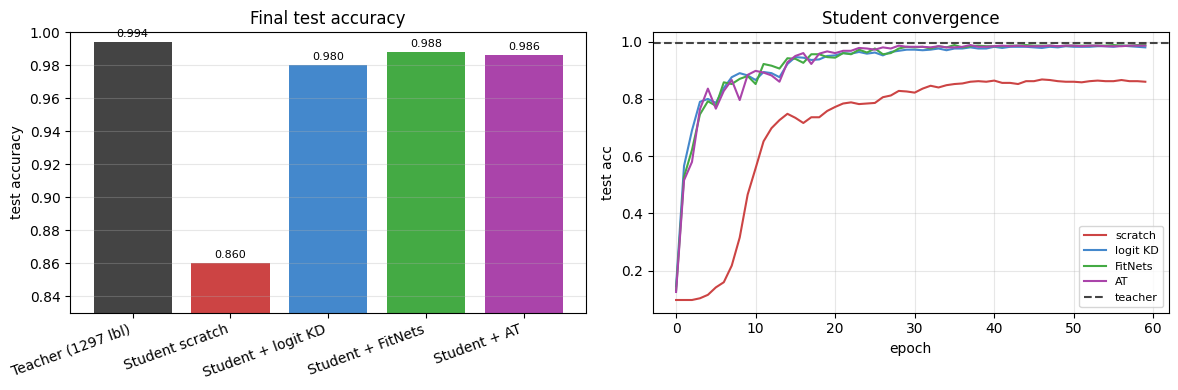

In [10]:
results = {
    'Teacher (1297 lbl)':  teacher_acc,
    'Student scratch':     acc_scratch,
    'Student + logit KD':  acc_kd,
    'Student + FitNets':   acc_fit,
    'Student + AT':        acc_at,
}
print('Test accuracy')
print('-' * 40)
for k, v in results.items():
    print(f'  {k:22s} {v:.4f}')
print('-' * 40)
print(f'scratch -> distilled gains (vs {acc_scratch:.3f}):')
for name, a in [('logit KD', acc_kd), ('FitNets', acc_fit), ('AT', acc_at)]:
    print(f'  {name:9s}: {(a-acc_scratch)*100:+.2f} pts')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
names = list(results); vals = list(results.values())
colors = ['#444','#c44','#48c','#4a4','#a4a']
ax[0].bar(range(len(names)), vals, color=colors)
ax[0].set_xticks(range(len(names))); ax[0].set_xticklabels(names, rotation=20, ha='right')
ax[0].set_ylim(min(vals)-0.03, 1.0); ax[0].set_ylabel('test accuracy')
ax[0].set_title('Final test accuracy'); ax[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(vals): ax[0].text(i, v+0.003, f'{v:.3f}', ha='center', fontsize=8)

ax[1].plot(hist_scratch, label='scratch', color='#c44')
ax[1].plot(hist_kd,  label='logit KD', color='#48c')
ax[1].plot(hist_fit, label='FitNets', color='#4a4')
ax[1].plot(hist_at,  label='AT', color='#a4a')
ax[1].axhline(teacher_acc, ls='--', color='#444', label='teacher')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('test acc'); ax[1].set_title('Student convergence')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. Did the feature distillation actually align the features?

Accuracy aside, the *direct* objective of FitNets/AT is to make the student's intermediate
representation resemble the teacher's. We check this on the test set with two measures:
- **Attention-map cosine similarity** between student and teacher (what AT optimizes).
- It should be **highest for the AT student**, and higher for FitNets than scratch.


In [11]:
@torch.no_grad()
def mean_attention_cosine(student):
    student.eval(); sims = []
    for xb, yb in test_loader:
        _, sf = student(xb); _, tf = teacher(xb)
        sa = attention_map(sf); ta = attention_map(tf)        # already L2-normalized
        sims.append((sa * ta).sum(1))                          # cosine per sample
    return torch.cat(sims).mean().item()

print('Student-vs-teacher attention-map cosine similarity (higher = features more aligned):')
for name, m in [('scratch', student_scratch), ('logit KD', student_kd),
                ('FitNets', student_fit), ('AT', student_at)]:
    print(f'  {name:9s}: {mean_attention_cosine(m):.4f}')


Student-vs-teacher attention-map cosine similarity (higher = features more aligned):
  scratch  : 0.8199
  logit KD : 0.8750
  FitNets  : 0.9193


  AT       : 0.9552


## 11. What the attention maps look like

The signal AT transfers: the teacher's spatial attention $\sum_c F_c^2$. The AT student is
trained to reproduce these maps — a softer, more transferable target than exact activations.


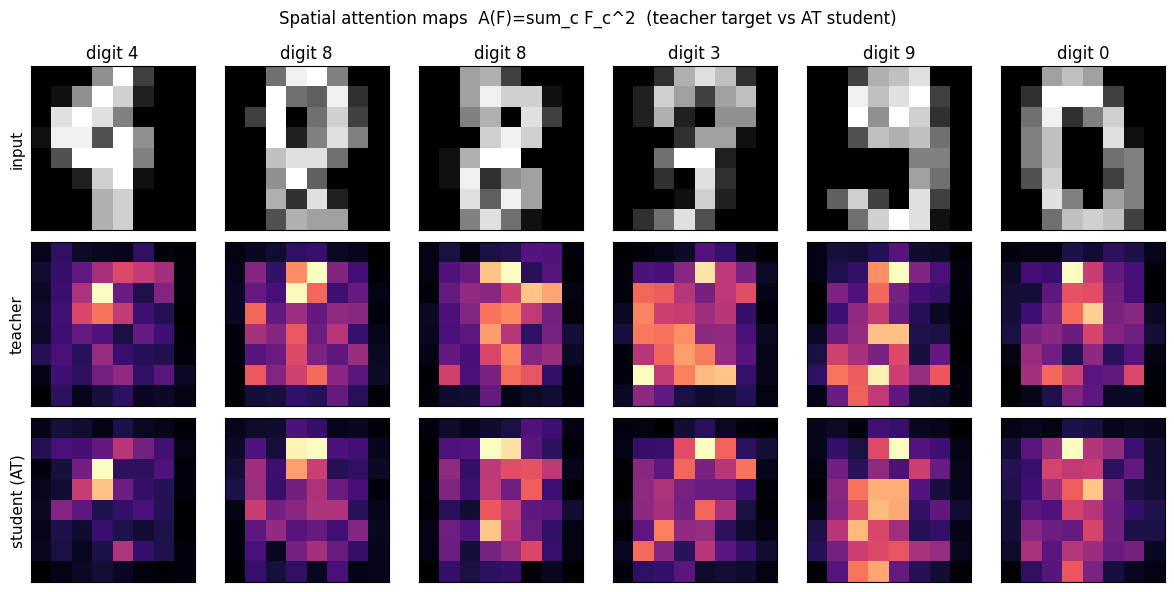

In [12]:
xb, yb = next(iter(test_loader))
with torch.no_grad():
    _, t_feat = teacher(xb[:6])
    _, s_feat = student_at(xb[:6])
t_att = (t_feat**2).sum(1).numpy()
s_att = (s_feat**2).sum(1).numpy()

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
row_titles = ['input', 'teacher', 'student (AT)']
for i in range(6):
    axes[0, i].imshow(xb[i, 0].numpy(), cmap='gray'); axes[0, i].set_title(f'digit {yb[i].item()}')
    axes[1, i].imshow(t_att[i], cmap='magma')
    axes[2, i].imshow(s_att[i], cmap='magma')
    for r in range(3): axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
for r, t in enumerate(row_titles):
    axes[r, 0].set_ylabel(t, fontsize=11)
plt.suptitle('Spatial attention maps  A(F)=sum_c F_c^2  (teacher target vs AT student)')
plt.tight_layout(); plt.show()


## 12. Takeaways

- With only 150 labels the **scratch** student is weak. The teacher's guidance on the 1147
  unlabeled transfer images closes most of the gap — this is the regime where distillation
  genuinely adds information.
- **Logit KD** already recovers most of the gap via soft targets.
- **FitNets** adds the full intermediate feature tensor through a **1×1 adapter** that bridges
  the 24→64 channel gap and is dropped at inference.
- **Attention Transfer** matches *where the network looks* — **no adapter** needed — and the
  alignment check (§10) confirms its attention maps are the closest to the teacher's.
- All feature methods are **combined with** CE + logit-KD, never used alone.

These mechanics — adapters for dimension mismatch, the transform `g(F)`, and loss weighting
`β` — are exactly what scales to ResNet / detector distillation. See
[knowledge_distillation.md](knowledge_distillation.md) §7–§9 for FSP, NST, PKT, RKD, CRD, OFD,
and ReviewKD.
